# 20. Swarmalators (different phases)
**Score: 0.6**

[![DOI](https://img.shields.io/badge/DOI-10.1038%2Fs41467--017--01190--3-blue.svg)](https://doi.org/10.1038/s41467-017-01190-3)
[![DOI](https://img.shields.io/badge/DOI-10.1209%2F0295--5075%2Fac8445-blue.svg)](https://iopscience.iop.org/article/10.1209/0295-5075/ac8445)


$$
{\dot {\bf x}}_i = {\bf{v}}_i + \frac{1}{N}\left[ {\mathop {\sum}\limits_{j \ne i}^N \frac{{{\bf{x}}_j - {\bf{x}}_i}}{{\left| {{\bf{x}}_j - {\bf{x}}_i} \right|}}\left( {A + J\,{\rm{cos}}\left( {\theta _j - \theta _i} \right)} \right) - B\frac{{{\bf{x}}_j - {\bf{x}}_i}}{{\left| {{\bf{x}}_j - {\bf{x}}_i} \right|^2}}} \right]
$$
$$
\dot \theta _i = \omega _i + \frac{K}{N}\mathop {\sum}\limits_{j \ne i}^N \frac{{{\rm{sin}}\left( {\theta _j - \theta _i} \right)}}{{\left| {{\bf{x}}_j - {\bf{x}}_i} \right|}}
$$
for $i=1,...,N$, where:
- $N$ is the population size
- $\bf{x}_i = (x_i, y_i)$ is the position of the i-th swarmalator
- $\theta_i$ is the swarmalator's phase
- $\omega_i$ is the swarmalator's natural frequency
- $\bf{v}_i$ is the swarmalator's self-propulsion velocity
- $A=B=1$ from rescaling time
- $K$ is the phase coupling strength
- $J$ measures the extend to which phase similarity enhances spatial attraction

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [2]:
def position(z, t, J, K, N, A=1, B=1, v=0, omega=0):
    x, theta = z[:2*N], z[2*N:]
    x = x.reshape(N,2)

    # we use broadcasting to compute xi-xj
    xi_xj = x[None,:,:] - x[:,None,:]
    normij = np.linalg.norm(xi_xj, axis=2)
    np.fill_diagonal(normij, np.inf)  # to avoid division by zero for i=j

    dist = xi_xj / normij[:,:,None]
    dist2 = xi_xj / normij[:,:,None]**2

    thetai_j = theta[None,:] - theta[:,None]
    cos_theta = np.cos(thetai_j)
    sin_theta = np.sin(thetai_j)

    attraction = dist*(A+J*cos_theta[:,:,None])
    repulsion = B*dist2

    xi = v + np.sum(attraction-repulsion, axis=1)/N
    thetai = omega + K/N*np.sum(sin_theta/normij, axis=1)

    return np.concatenate([xi.ravel(), thetai])

In [3]:
np.random.seed(810)

N = 100 #to put 1000

# positioning the particles random uniformly between -1 and 1
x0 = np.random.uniform(-1, 1, (N,2))
# having phase between -pi and pi
theta0 = np.random.uniform(-np.pi, np.pi, N)

z0 = np.concatenate([x0.ravel(), theta0])
t = np.arange(start=0, stop=100, step=0.1)


$K_c\approx-1.2J$

$$
W_ \pm = S_ \pm e^{i{\rm{\Psi }}_ \pm } = \frac{1}{N}\mathop {\sum}\limits_{j = 1}^N e^{i\left( {\phi _j \pm \theta _j} \right)}
$$
with:
$\phi _i: = {\rm{tan}}^{ - 1}\left( {y_i{\rm{/}}x_i} \right)$. We can write $S_ \pm = \mid W_\pm \mid = \sqrt{A_\pm^2 + B_\pm^2}$, being $A_\pm = \frac{1}{N} \sum_j^N \cos{(\phi_j \pm \theta_j)}$ and $B_\pm = \frac{1}{N} \sum_j^N \sin{(\phi_j \pm \theta_j)}$

$$
R = (1+J)^{-1/2}
$$
$$
R_1 = {\it{\Delta }}_J\frac{{ - \sqrt 3 J - 3\sqrt {12 - 5J} \sqrt {J + 4} + 12\sqrt 3 }}{{12J}}
$$
$$
R_2 = \frac{{{\it{\Delta }}_J}}{{2\sqrt 3 }}
$$
with ${\it{\Delta }}_J = \sqrt {\frac{{3J - \sqrt {36 - 15J} \sqrt {J + 4} - 12}}{{J - 2}}}$

TO DO: 
- i have to define $\gamma$ to distinguish between active phase wave and splintered phase wave
- for $K=0$ but $J<0$ static async or sync state?

In [16]:
def set_title(S, J, K):
    Kc = -1.2*J

    if K>0:
        title = 'Static Sync state'
    if K==0:
        title = 'Static Phase Wave state'
    if K<0:
        if J<Kc:
            title = 'Static Async state'
        else:
            # add condition to distinguish between the two dynamic phase
            title = 'Dynamic state'
    
    return title

In [ ]:
def solution(J, K, z0, t, N):

    sol = odeint(position, z0, t, args=(J, K, N))
    positions = sol[:,:2*N].reshape(len(t), N, 2)
    phases = sol[:,2*N:]

    # compute S
    xi, yi = positions[:,:,0], positions[:,:,1]

    phi = np.arctan2(yi, xi)

    Wp = np.mean(np.exp(1j * (phi + phases[:,:])), axis=1)
    Wm = np.mean(np.exp(1j * (phi - phases[:,:])), axis=1)
    
    Sp, Sm = np.abs(Wp), np.abs(Wm)
    S = np.max(np.vstack((Sp, Sm)), axis=0)

    # compute R
    Kc = -1.2*J
    if K>0:
        R = (1+J)**(-0.5)
        R1, R2 = None, None
    elif K==0 or J>=Kc:
        deltaJ = np.sqrt((3*J - np.sqrt(36 - 15*J)*np.sqrt(J + 4) - 12)/(J - 2))
        R1 = deltaJ*(-np.sqrt(3)*J - 3*np.sqrt(12 - 5*J)*np.sqrt(J + 4) + 12*np.sqrt(3))/(12*J)
        R2 = deltaJ/(2*np.sqrt(3))
        R = None
    else:
        R = 1
        R1, R2 = None, None
    title = set_title(S=S, J=J, K=K)

    # rivedere S
    #------------------------------------------------------------------------------------
    # compute gamma
    transient = int(len(t)*0.5) # first half transients
    xi, yi = xi[transient:], yi[transient:]
    phases = phases[transient:]

    # averaging over the population
    xc, yc = np.mean(xi, axis=1), np.mean(yi, axis=1)
    # angle around the centroid
    phi = np.arctan2(yi-yc[:,None], xi-xc[:,None])
    
    
    plt.scatter(xc[0], yc[0], c='r')
    #------------------------------------------------------------------------------------

    # plotting only the time step T=100
    plt.scatter(positions[-1, :, 0], positions[-1, :, 1], c=phases[-1,:])
    plt.title(f'{title} (J,K) = {J, K}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

    params = {'S':S,
              'R':R,
              'R1':R1,
              'R2':R2}

    return params

(500,)
(500, 1)


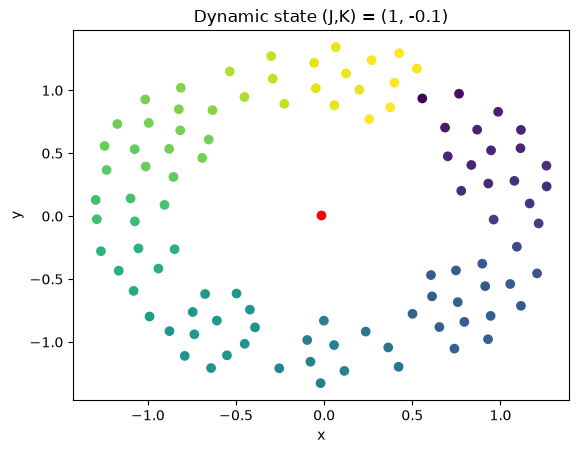

In [44]:
S_active = solution(1, -0.1, z0, t, N)

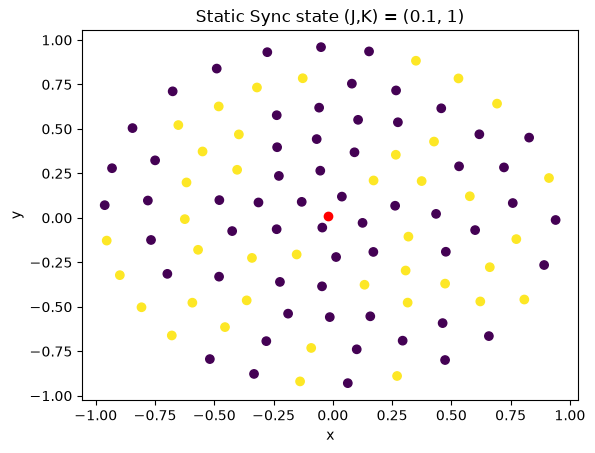

In [36]:
S_sync = solution(0.1, 1, z0, t, N)

J=0.1, Kc=-0.12


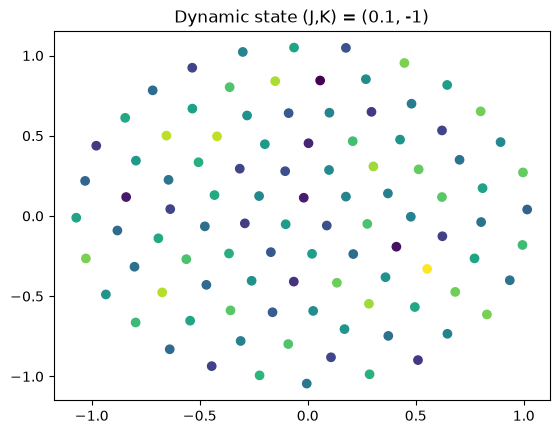

In [12]:
S_async = solution(0.1, -1, z0, t, N)

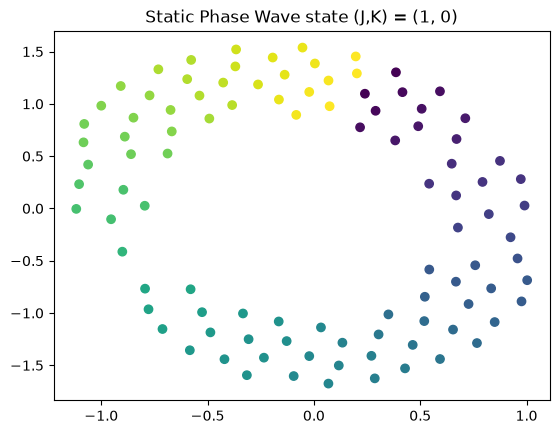

In [13]:
S_phase = solution(1, 0, z0, t, N)

J=1, Kc=-1.2


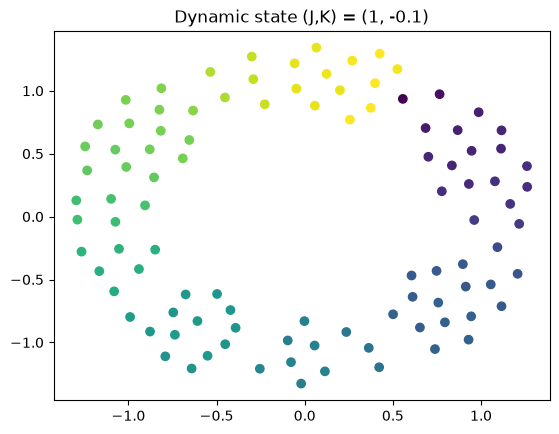

In [15]:
# should be splintered
S_splintered = solution(1, -0.1, z0, t, N)

J=1, Kc=-1.2


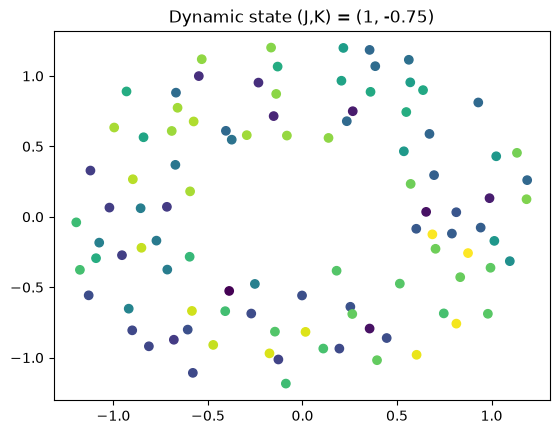

In [90]:
S_active = solution(1, -0.75, z0, t, N)